# توقع كمية الغيم وخريطته بعد ساعة

ده نفس مشروعك كامل بتجربتين: Station CNN بتتوقع تغير clamt في خمس محطات بعد ساعة، وبعدها CNN–LSTM بتتوقع cloud map وcloud-top height map للساعة الجاية. الرسومات النهائية والـrecorded وpredicted maps بألوان المشروع الأصلية موجودة.

بنمشي على خطوات المحاضرة: فحص الداتا، تقسيم زمني 70/15/15 من غير overlap، scaling من Train فقط، persistence قبل model، توقع التغير، اختيار الأوزان على Validation، وتقييم Test. لازم تشغيل كل الخلايا من الأول لأن نتائج 3 ساعات وتقسيم الأسابيع القديمة مش صالحة هنا.


## تجهيز الـenvironment

الخلية اللي جاية بتثبت الـpackages المطلوبة لو مش موجودة. بعد التثبيت ممكن تحتاجي تعملي Restart للـkernel قبل ما تكمّلي.


In [1]:
%pip install matplotlib numpy pandas torch


Note: you may need to restart the kernel to use updated packages.


هنا بنعمل import للمكتبات اللي هنستخدمها في الحسابات، الرسومات، وبناء الـneural networks.


الـimports دي مشتركة بين التجربتين، لكن كل تجربة ليها الـmodel والـloss والـmetrics بتوعها.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import torch, torch.nn as nn
import pandas as pd
import copy

torch.cuda.is_available()


False

بنتأكد من نسخة PyTorch وهل CUDA متاحة. لو فيه GPU التدريب هيبقى أسرع؛ لو مفيش، نفس الكود هيشتغل على CPU.


In [3]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())


PyTorch: 2.14.0+cpu
CUDA available: False
GPU count: 0


## قراءة الداتا ومراجعة الوقت

قبل ما نكوّن أي training samples، لازم نفهم ملفات الـsatellite والمحطات ونتأكد إن ساعاتهم متطابقة.


بنفتح ملف الـNPZ بتاع 2024 ونشوف `times` و`cloud_mask` و`cth_km` و`lat` و`lon`. الـmask بيفرق بين الغيم والـno data، وارتفاع الغيم بالكيلومتر. الـno data مش معناها سماء صافية.


In [4]:
sat_data = np.load( 
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)
print(sat_data.files)


['times', 'cloud_mask', 'cth_km', 'lat', 'lon']


بنحدد ملفات الـCSV بتاعة المحطات الخمس وبنجهز دالة لقراءة `clamt`. دي كمية الغيم بوحدة oktas من 0 لـ8.


In [5]:
csv_name = ["hly532.csv", "hly3904_subset.csv", "hly4935_subset.csv",
            "hly518_subset.csv", "hly3723_subset.csv"]
dates = []

def get_target_data(csv_name):
    data = pd.read_csv("data/raw/stations/" + csv_name, skiprows=41,
                       usecols=["date", "clamt"], low_memory=False)
    data["date"] = pd.to_datetime(data["date"], format="%d-%b-%Y %H:%M")
    data = data.loc[data["date"].dt.year == 2024].copy()
    if data["date"].duplicated().any():
        raise ValueError(f"Duplicate hours in {csv_name}")
    target = pd.to_numeric(data["clamt"], errors="coerce")
    target = target.where(target.between(0, 8)).to_numpy(dtype=np.float32)
    dates.append(data["date"].to_numpy())
    print(f"{csv_name}: {len(target)} hours; missing clamt: {np.isnan(target).sum()}")
    return target


بنقرأ قياسات كل محطة حسب الوقت. في الآخر هيبقى عندنا سلسلة ساعية مستقلة لكل محطة.


In [6]:
target_data = []

for csv in csv_name:
    target_data.append(get_target_data(csv))


hly532.csv: 8784 hours; missing clamt: 0
hly3904_subset.csv: 8784 hours; missing clamt: 0
hly4935_subset.csv: 8784 hours; missing clamt: 0
hly518_subset.csv: 8784 hours; missing clamt: 0
hly3723_subset.csv: 8784 hours; missing clamt: 0


بنتأكد إن ساعات ملفات المحطات ماشية بنفس الترتيب؛ لو ترتيب الوقت غلط، الـinput هيتربط بـtarget من ساعة مختلفة.


In [7]:
dates = np.array(dates).T
print(f"dates shape: {dates.shape}")

for date in dates:
    assert np.all(date[0] == date[1 :]), "Dates are not the same across all CSV files."


dates shape: (8784, 5)


بنحط قياسات المحطات الخمس في array واحدة: كل صف ساعة، وكل عمود محطة. ترتيب المحطات هنا لازم يفضل ثابت لحد التقييم.


In [8]:
target_data = np.array(target_data)
print(f"target_data shape: {target_data.shape}")


target_data shape: (5, 8784)


بنطابق ساعة الـsatellite مع الساعة المقابلة في المحطات، عشان الصورة والقياس اللي في نفس الصف يخصّوا نفس الوقت.


In [9]:
cloud_mask = sat_data["cloud_mask"]
cth_km = sat_data["cth_km"]
sat_times = sat_data["times"]

# station rows must be the same hours in the same order as the satellite frames (all UTC)
assert np.array_equal(dates[:, 0].astype("datetime64[us]"), sat_times)

# one True/False per HOUR: missing only if the WHOLE frame is "no data" (3)


بنحدد الساعات اللي فيها على الأقل pixel صالح في الصورة، وكمان بيانات المحطات المطلوبة متاحة. الساعات غير الصالحة مش هتدخل في أمثلة التدريب.


In [10]:
sat_ok = ~(cloud_mask == 3).all(axis=(1, 2))                 # (8784,)

# target_data is (stations, hours): an hour is usable only if EVERY station has a cloud amount,
# so collapse the station axis -> one value per hour
target_ok = ~np.isnan(target_data).any(axis=0)               # (8784,)

hour_ok = sat_ok & target_ok
print(f"hours: {len(hour_ok)}, missing: {(~hour_ok).sum()}")
print("missing hours:", sat_times[~hour_ok])


hours: 8784, missing: 14
missing hours: ['2024-06-27T07:00:00.000000' '2024-07-23T22:00:00.000000'
 '2024-07-23T23:00:00.000000' '2024-07-24T00:00:00.000000'
 '2024-07-24T01:00:00.000000' '2024-07-24T02:00:00.000000'
 '2024-07-24T03:00:00.000000' '2024-07-24T04:00:00.000000'
 '2024-08-17T13:00:00.000000' '2024-08-17T14:00:00.000000'
 '2024-08-17T15:00:00.000000' '2024-08-17T16:00:00.000000'
 '2024-08-17T17:00:00.000000' '2024-09-04T08:00:00.000000']


بنجهز صورتين لكل ساعة بحجم `90 × 120`: واحدة بتوضح وجود الغيم، والتانية ارتفاع قمته. الـpixels المفقودة ماينفعش نتعامل معاها كإنها غيم مرصود.


In [11]:
# Build 2 channels per timestep -> frames: (hours, 2, 90, 120)
#   channel 0: cloud      1 = cloud, 0 = clear (clear sea / clear land / no-data pixel)
#   channel 1: height_km  cloud top height in km, 0 where clear
# Sea vs land never changes, so it's not worth a channel of its own.

cloud = (cloud_mask == 2).astype(np.float16)

# cth_km is NaN only in the 14 missing hours (those samples get dropped anyway) -> 0.
# CTH comes on a coarser grid, so it spills onto some clear pixels -- zero it wherever
# the cloud mask says clear so the two channels agree.
height_km = np.nan_to_num(cth_km, nan=0.0) * cloud

frames = np.stack([cloud, height_km], axis=1)    # float16 to save memory (~380 MB)



print(f"frames shape: {frames.shape}  (hours, channels, lat, lon)")
print(f"height range: {height_km.min():.2f} - {height_km.max():.2f} km")


frames shape: (8784, 2, 90, 120)  (hours, channels, lat, lon)
height range: 0.00 - 15.04 km


بعد ما جهزنا الصور، بنفضّي الـarrays الوسيطة الكبيرة عشان نوفر RAM. ده مش بيغير الداتا اللي هتدخل الـmodel.


In [12]:
import gc
del cloud, height_km, cth_km, sat_ok
gc.collect()


161

## Station CNN: توقع clamt بعد ساعة

الـoutput خمس قيم oktas لمحطات الرصد عند t+1. بعد القسم ده هتلاقي تدريب CNN–LSTM للخريطة كاملة في نفس الـnotebook.


بنستخدم K=6 صور متتالية وH=1 ساعة: آخر input عند 10:00، وtarget عند 11:00، بنفس أفق توقع الخريطة.


In [13]:
K = 6  # six consecutive hourly satellite maps
H = 1  # one-hour clamt forecast, matching the next-hour map
sample_t = np.array([
    t for t in range(K - 1, len(hour_ok) - H)
    if hour_ok[t - K + 1:t + 1].all() and hour_ok[t + H]
])
print(f"possible samples: {len(hour_ok) - H - K + 1}, kept: {len(sample_t)}, "
      f"dropped: {len(hour_ok) - H - K + 1 - len(sample_t)}")


possible samples: 8778, kept: 8740, dropped: 38


بنبص على أول sample: شكل الصور الست وشكل الـtarget للمحطات الخمس. دي مراجعة بسيطة بس مهمة عشان نكشف أي غلط في الوقت أو الـshape.


In [14]:
t = sample_t[0]
X0 = frames[t - K + 1:t + 1]        # (K, 2, 90, 120): K timesteps x 2 channels
y0 = target_data[:, t + H]          
print(X0.shape, y0)


(6, 2, 90, 120) [1. 7. 6. 4. 2.]


الـtarget هو التغير clamt(t+1) − clamt(t). بنضيفه للقياس الحالي وقت الـprediction، زي predict change في المحاضرة.


In [15]:
clamt_now    = target_data[:, sample_t].T        # (samples, stations) cloud amount at the last input hour t
clamt_future = target_data[:, sample_t + H].T    # (samples, stations) cloud amount at t + H
y = clamt_future - clamt_now                     # (samples, stations) change in oktas over the next H hours
print(f"y shape: {y.shape}  (samples, stations)")


y shape: (8740, 5)  (samples, stations)


بنضيف 7 features جنب الصور: الخمس قيم الحالية للمحطات، ومعاهم `sin` و`cos` لساعة الـtarget. الـsin/cos بيمثلوا دوران اليوم، فـ23:00 و00:00 يفضلوا قريبين من بعض.


In [16]:
# extra inputs per sample, joined to the CNN features before the final layer
#   clamt_now / 8        -> (samples, 5)  current cloud amount at each station, 0-1
#   sin/cos hour of day  -> (samples, 2)  hour of the TARGET (t + H), so 23h sits next to 0h
target_hour = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
extra = np.column_stack([
    clamt_now / 8.0,
    np.sin(2 * np.pi * target_hour / 24),
    np.cos(2 * np.pi * target_hour / 24),
]).astype(np.float32)
print(f"extra shape: {extra.shape}  (samples, 5 stations + 2 hour)")


extra shape: (8740, 7)  (samples, 5 stations + 2 hour)


بنعمل التقسيم على ساعات السنة، ونتأكد إن الصور الست والـtarget لكل sample جوه نفس الجزء.


In [17]:
n_hours = len(sat_times)
train_end = int(0.70 * n_hours)
validation_end = int(0.85 * n_hours)
first_input = sample_t - K + 1
target_hour_index = sample_t + H
inside_train = target_hour_index < train_end
inside_validation = (first_input >= train_end) & (target_hour_index < validation_end)
inside_test = first_input >= validation_end


أول 70% من ساعات السنة Train، بعدها 15% Validation، وآخر 15% Test بالترتيب، زي المحاضرة. بنسقط أي sample بيعبر حدود قسمين.


In [18]:
idx = np.arange(len(sample_t))
train_idx = idx[inside_train]
val_idx = idx[inside_validation]
test_idx = idx[inside_test]

def used_station_hours(indices):
    ends = sample_t[indices]
    return set(np.concatenate([ends - offset for offset in range(K)] + [ends + H]))

assert used_station_hours(train_idx).isdisjoint(used_station_hours(val_idx))
assert used_station_hours(train_idx).isdisjoint(used_station_hours(test_idx))
assert used_station_hours(val_idx).isdisjoint(used_station_hours(test_idx))
for label, rows in (("Train", train_idx), ("Validation", val_idx), ("Test", test_idx)):
    target_times = sat_times[sample_t[rows] + H]
    print(f"{label}: {len(rows)} samples | {target_times[0]} to {target_times[-1]}")
print("No shared input or target hours between splits.")


Train: 6104 samples | 2024-01-01T06:00:00.000000 to 2024-09-13T03:00:00.000000
Validation: 1312 samples | 2024-09-13T10:00:00.000000 to 2024-11-07T01:00:00.000000
Test: 1312 samples | 2024-11-07T08:00:00.000000 to 2024-12-31T23:00:00.000000
No shared input or target hours between splits.


### Persistence baseline قبل Station CNN

بنقيس قيمة clamt الحالية كـforecast للساعة الجاية قبل ما ندرّب model. RMSE بالـoktas؛ Test baseline للمقارنة بس، مش لتعديل parameters.


In [19]:
def overall_rmse(predicted, observed):
    return np.sqrt(np.mean((predicted - observed) ** 2))

for name, indices in (("Validation", val_idx), ("Test", test_idx)):
    print(f"{name} persistence RMSE: "
          f"{overall_rmse(clamt_now[indices], clamt_future[indices]):.3f} oktas")


Validation persistence RMSE: 1.206 oktas
Test persistence RMSE: 1.225 oktas


بنجهز `scikit-learn` عشان نعمل baseline بسيط للمحطات ونشوف هل الـCNN بتضيف فايدة فعلًا.


In [20]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


بنستورد `LinearRegression`. ده baseline منفصل، مش layer جوّه الـCNN ولا جزء من نموذج الخرائط.


In [21]:
from sklearn.linear_model import LinearRegression


بندرّب LinearRegression على Train فقط باستخدام الـfeatures غير الصورية، وبنقيس Validation قبل Test.


In [22]:
lin = LinearRegression().fit(extra[train_idx], y[train_idx])


بنقيس الـlinear baseline على Validation دلوقتي، وهنعرض Test score بتاعها مع CNN وباقي الـbaselines في الآخر.


In [23]:
linear_val = np.clip(clamt_now[val_idx] + lin.predict(extra[val_idx]), 0, 8)
print(f"Linear baseline Validation RMSE: "
      f"{overall_rmse(linear_val, clamt_future[val_idx]):.3f} oktas")


Linear baseline Validation RMSE: 1.124 oktas


بنجهز دالة تحسب `mean` و`std` لقنوات الصور على دفعات؛ كده مش محتاجين نحمل كل الصور في الـRAM مرة واحدة.


In [24]:
def channel_stats(frames, hours, chunk=256):
    C = frames.shape[1]
    s, ss, count = np.zeros(C), np.zeros(C), 0
    for j in range(0, len(hours), chunk):
        b = frames[hours[j:j + chunk]].astype(np.float64)   # (b, C, 90, 120)
        s  += b.sum(axis=(0, 2, 3))                         # sum over everything except channel
        ss += (b ** 2).sum(axis=(0, 2, 3))
        count += b[:, 0].size
    mean = s / count
    std = np.sqrt(ss / count - mean ** 2)
    return mean, np.where(std == 0, 1.0, std)

# every input hour touched by a training sample (first frame of the first sample -> last frame of the last)


بنحسب x_mean وx_std من ساعات صور Train المستخدمة فعليًا، وy_mean وy_std من Train targets فقط؛ مفيش تسرب من Validation أو Test.


In [25]:
train_hours = np.unique((sample_t[train_idx, None] - np.arange(K)[None, :]).ravel())
x_mean, x_std = channel_stats(frames, train_hours)
y_mean, y_std = y[train_idx].mean(axis=0), y[train_idx].std(axis=0)
y_std = np.where(y_std < 1e-6, 1.0, y_std)
print("Training image hours used for scaling:", len(train_hours))


Training image hours used for scaling: 6129


بنعرّف الـDataset: لكل sample بيجهز الصور الست، والـ7 features الإضافيين، وخمس قيم تمثل التغير المطلوب في المحطات.


In [26]:
class FrameDataset(torch.utils.data.Dataset):
    def __init__(self, frames, extra, y, sample_t, idx, K):
        self.frames, self.extra, self.y, self.sample_t, self.idx, self.K = frames, extra, y, sample_t, idx, K
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        t = self.sample_t[j]
        x = self.frames[t - self.K + 1:t + 1]
        return (torch.from_numpy(x.astype(np.float32)),
                torch.from_numpy(self.extra[j]),
                torch.from_numpy(self.y[j].astype(np.float32)))


بنعمل DataLoader للـtrain بـ`batch_size=32` مع `shuffle=True`، وللـvalidation والـtest بـ64 من غير خلط. ممكن نجرب batch أصغر لو الـRAM قليلة، ونقارن بالـvalidation.


In [27]:
train_loader = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, train_idx, K), batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, val_idx, K),   batch_size=64)
test_loader  = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, test_idx, K),  batch_size=64)


## إزاي Station CNN بتحوّل 6 صور لـ5 توقعات؟

دي تجربة المحطات: فيها **CNN من غير LSTM**. كل ساعة ليها قناتين (الغيم والارتفاع)، والست ساعات بيتحطوا جنب بعض كـchannels. الـoutput هو التغير المتوقع في oktas لكل محطة بعد ساعة واحدة.

| المرحلة | الـinput → الـoutput لكل sample | إيه اللي بيحصل وليه؟ |
| --- | --- | --- |
| تجميع الصور | `6 × 2 × 90 × 120` → `12 × 90 × 120` | بنحط الست ساعات في 12 channels؛ مفيش recurrent state في النموذج ده. |
| CNN block 1 | `12 × 90 × 120` → `16 × 44 × 59` | `Conv2d(12,16,3,stride=2,padding=0)` تلتقط patterns محلية وتقلل المقاس، وبعدها `BatchNorm2d` و`GELU`. |
| CNN block 2 | `16 × 44 × 59` → `32 × 21 × 29` | `kernel_size=3`, `stride=2`, `padding=0`، وبعدها `BatchNorm2d` و`GELU`. |
| CNN block 3 | `32 × 21 × 29` → `64 × 10 × 14` | نفس الإعدادات. التصغير هنا بسبب `stride=2`؛ مفيش pooling جوّه الـblocks. |
| Average pooling | `64 × 10 × 14` → `64 × 6 × 8` | `AdaptiveAvgPool2d((6,8))` بتاخد المتوسط عشان تنتج حجم ثابت؛ مش max pooling. |
| Flatten ودمج | `64 × 6 × 8` → `3072`؛ ثم `3072 + 7 = 3079` | بنضيف قيم المحطات الحالية الخمس و`sin/cos` لساعة الـtarget. |
| Prediction head | `3079` → `5` | `Dropout(0.3)` يساعد يقلل overfitting، وبعده `Linear(3079,5)` يطلع التغيرات بعد scaling. مفيش sigmoid لأن التغير ممكن يكون سالب. |

`ScaledModel` بيظبط scale الـinputs والـtargets. وقت التوقع بنرجّع الفرق لوحدة oktas ونضيفه للقياس الحالي. الأعداد 16 و32 و64 معناها **feature channels**، مش عدد neurons في طبقة fully connected. لو هنغيّر عدد الـfilters أو `Dropout`، نحكم من أداء الـvalidation.


الخلية دي محتفظة بـnotes قديمة عن ConvLSTM كنص غير منفذ. خلي بالك: Station CNN اللي بندرّبها هنا **مافيهاش LSTM**.


In [28]:
###
#Failed attemp to use ConvLSTM from github
###
"""from class_convlstm import ConvLSTM

convlstm_layer = []
img_size_list = [(90, 120)]
num_layers = 3
input_channel = 2
hidden_channel = 64
kernel_size = (3, 3)
stride = (1, 1)
padding = (1, 1)
for i in range(num_layers):
    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,
                  stride=stride, padding=padding, batch_first=True)
    )
    input_channel = hidden_channel
"""


'from class_convlstm import ConvLSTM\n\nconvlstm_layer = []\nimg_size_list = [(90, 120)]\nnum_layers = 3\ninput_channel = 2\nhidden_channel = 64\nkernel_size = (3, 3)\nstride = (1, 1)\npadding = (1, 1)\nfor i in range(num_layers):\n    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,\n                  stride=stride, padding=padding, batch_first=True)\n    )\n    input_channel = hidden_channel\n'

هنا بنحدد أبعاد الـchannels والـfilters اللي هنستخدمها في Station CNN. لازم الأبعاد دي توافق عدد channels في الصور ومدخلات الـLinear layer.


In [29]:
input_channel = 2
kernel_size = (3, 3)
stride = (2, 2)
padding = (0, 0)


بنعمل block ترتيبها `Conv2d → BatchNorm2d → GELU`. الـConv تلتقط أشكال الغيم، والـBatchNorm تساعد التدريب يبقى مستقر، والـGELU تضيف nonlinearity. في النموذج ده `stride=2` و`padding=0`.


In [30]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)    # matches out_channels
        self.gelu = nn.GELU()


    def forward(self, x):
        return self.gelu(self.bn(self.conv(x)))   # uses the names defined above


في `CloudCNN.forward` الصور بتعدّي على CNN blocks وبعدين pooling وflatten، وبعدها بنضم الـ7 features ونطلع خمس توقعات. ده اسمه forward pass؛ لسه الأوزان ما اتحدّثتش.


In [31]:
class CloudCNN(nn.Module):
    def __init__(self, K, n_channels, n_stations, n_extra):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(K * n_channels, 16, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(16, 32, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(32, 64, stride=stride, padding=padding, kernel_size=kernel_size),
        )
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 8)),              # -> (B, 64, 6, 8)
            nn.Flatten(),                              # -> (B, 3072)
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * 6 * 8 + n_extra, n_stations),   # -> (B, 5)
        )

    def forward(self, x, extra):
        B, K, C, H, W = x.shape
        x = x.reshape(B, K * C, H, W)
        z = self.pool(self.features(x))                # (B, 3072) image features
        z = torch.cat([z, extra], dim=1)               # (B, 3072 + 7)
        return self.head(z)


بنلف الـmodel داخل `ScaledModel` عشان المدخلات والـtargets يبقوا على scale مناسب للـtraining. بعد الـprediction بنرجّع القيم لوحدة oktas.


In [32]:
class ScaledModel(nn.Module):
    def __init__(self, net, x_mean, x_std, y_mean, y_std):
        super().__init__()
        self.net = net
        f = lambda a: torch.tensor(a, dtype=torch.float32)
        self.register_buffer("x_mean", f(x_mean).view(1, 1, -1, 1, 1))   # broadcasts over (B, K, C, H, W)
        self.register_buffer("x_std",  f(x_std).view(1, 1, -1, 1, 1))
        self.register_buffer("y_mean", f(y_mean).view(1, -1))            # broadcasts over (B, stations)
        self.register_buffer("y_std",  f(y_std).view(1, -1))

    def scale_y(self, y):                 # training targets -> scaled
        return (y - self.y_mean) / self.y_std

    def forward_scaled(self, x_raw, extra):      # raw frames -> scaled change (training)
        return self.net((x_raw - self.x_mean) / self.x_std, extra)

    def forward(self, x_raw, extra):             # raw frames -> change in oktas (test)
        return self.forward_scaled(x_raw, extra) * self.y_std + self.y_mean


بننشئ Station CNN ونحطها على نفس الـdevice اللي هتروح له دفعات التدريب: GPU لو متاح، أو CPU لو مش متاح.


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScaledModel(CloudCNN(K, frames.shape[1], y.shape[1], extra.shape[1]),
                    x_mean, x_std, y_mean, y_std).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


parameters: 40,504


## Station loss والـforward/backward pass

في الـforward pass الـCNN بتطلع 5 توقعات: تغير كمية الغيم المقيسة في كل محطة. `MSELoss` بتحسب **متوسط مربع الفرق** بين التوقع والحقيقة بعد scaling؛ عشان كده أرقام الـloss هنا مش oktas ولا نسب مئوية.

لكل batch: `optimizer.zero_grad()` بتصفر gradients القديمة، بنحسب الـprediction والـloss، وبعدين `loss.backward()` ترجع gradients من آخر layer لحد CNN، و`optimizer.step()` تحدث الأوزان. بنستخدم `AdamW(lr=3e-4, weight_decay=1e-2)`، و`ReduceLROnPlateau` بتخفض learning rate للنص بعد 3 epochs من غير تحسن في validation. الـvalidation نفسها مابتعملش تحديث أوزان، وبنحتفظ بأفضل checkpoint حسب validation loss. لو هنغيّر learning rate أو weight decay، نقارن على validation فقط.


بنحدد `MSELoss`، و`AdamW` بـ`learning rate = 0.0003` و`weight_decay = 0.01`، وscheduler ينصّف الـlearning rate بعد 3 epochs من غير تحسن. دي loss مقيسة، مش RMSE بوحدة oktas.


In [34]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)   # <- was Adam, lr=1e-3
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)


50 epochs كحد أقصى، مع early stopping بعد 6 epochs من غير تحسن في Validation. بنبدأ loss lists فاضية لكل تجربة.


In [35]:
num_epochs = 50
patience = 6
best_val, best_state = float("inf"), None
stale_epochs = 0
train_loss_list, val_loss_list = [], []


الـtraining loop ماشي بالترتيب: `zero_grad → forward → MSE loss → backward → optimizer.step`. بعد كل epoch بنقيس validation loss من غير تحديث، وبنحفظ أفضل أوزان.


In [36]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, eb, yb in train_loader:
        xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model.forward_scaled(xb, eb), model.scale_y(yb))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, eb, yb in val_loader:
            xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
            val_loss += criterion(model.forward_scaled(xb, eb), model.scale_y(yb)).item() * len(xb)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= patience:
            print(f"Stopped after {patience} epochs without Validation improvement")
            break

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    print(f"epoch {epoch + 1}: train {train_loss:.4f}  val {val_loss:.4f}  (scaled MSE)")


epoch 1: train 1.0396  val 0.9594  (scaled MSE)
epoch 2: train 0.9608  val 0.9581  (scaled MSE)
epoch 3: train 0.9174  val 0.9520  (scaled MSE)
epoch 4: train 0.8740  val 0.9567  (scaled MSE)
epoch 5: train 0.8347  val 0.9937  (scaled MSE)
epoch 6: train 0.8017  val 0.9737  (scaled MSE)
epoch 7: train 0.7665  val 1.0014  (scaled MSE)
epoch 8: train 0.7088  val 0.9783  (scaled MSE)
Stopped after 6 epochs without Validation improvement


بنرجع لأوزان أقل validation loss بدل ما نفترض إن آخر epoch هي الأفضل. الـtest مش بيتستخدم لاختيار الـcheckpoint.


In [37]:
model.load_state_dict(best_state)
print(f"best val: {best_val:.4f}")


best val: 0.9520


### قراءة Station loss graph

محور x هو epochs اللي اتنفذت فعلًا، ومحور y هو scaled MSE، مش oktas. لو Train بتنزل وValidation بتزيد عدة epochs ده مؤشر overfitting؛ لو الأداء مستقر عدة epochs ده plateau. نتائج الرسم القديمة تخص هدف 3 ساعات وتقسيم تاني؛ لازم نفسّر الرسم الجديد بعد إعادة التدريب.


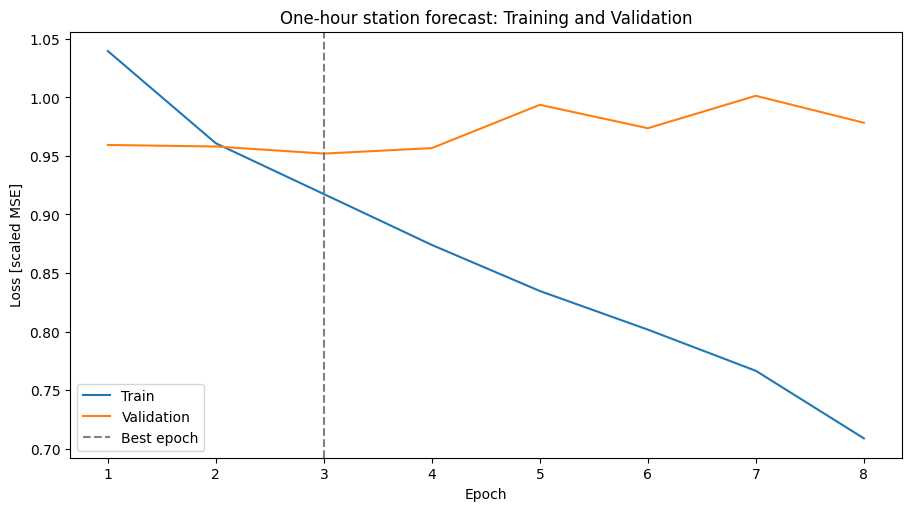

In [38]:
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
epochs = np.arange(1, len(train_loss_list) + 1)
ax.plot(epochs, train_loss_list, label="Train")
ax.plot(epochs, val_loss_list, label="Validation")
ax.axvline(np.argmin(val_loss_list) + 1, color="grey", ls="--", label="Best epoch")
ax.set(xlabel="Epoch", ylabel="Loss [scaled MSE]",
       title="One-hour station forecast: Training and Validation")
ax.legend()
plt.show()


بنستخدم Station CNN بعد اختيار أفضل weights عشان نتوقع clamt لعينات Test الزمنية. بنضيف التغير المتوقع لآخر قياس ونخلي النتيجة بين 0 و8 oktas.


In [39]:
model.eval()
preds = []
with torch.no_grad():
    for xb, eb, _ in test_loader:
        preds.append(model(xb.to(device), eb.to(device)).cpu().numpy())    # plain forward -> change in oktas
# forecast = cloud amount now + predicted change, kept inside 0-8
preds = np.clip(clamt_now[test_idx] + np.concatenate(preds), 0, 8)
y_true = clamt_future[test_idx]

# baseline 1: persistence = the cloud amount at t stays the same until t + H


بنجهز persistence وclimatology وhour-of-day baselines للتوقع بعد ساعة. persistence ممكن تكون صعبة المنافسة في forecast قصير.


In [40]:
persistence = clamt_now[test_idx]
climatology = np.broadcast_to(clamt_future[train_idx].mean(axis=0), y_true.shape)
hour_of_day = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
hourly_mean = np.array([
    clamt_future[train_idx][hour_of_day[train_idx] == h].mean(axis=0)
    for h in range(24)
])
diurnal = hourly_mean[hour_of_day[test_idx]]
linear_test = np.clip(clamt_now[test_idx] + lin.predict(extra[test_idx]), 0, 8)


بنقارن RMSE بالـoktas على نفس Test hours لكل الـmodels. أرقام 3 ساعات القديمة مالهاش علاقة بالتجربة الجديدة.


In [41]:
rmse = lambda a, b: np.sqrt(((a - b) ** 2).mean(axis=0))
for name, p in [
    ("Station CNN", preds), ("persistence", persistence),
    ("linear on extra", linear_test), ("climatology", climatology),
    ("hour-of-day mean", diurnal),
]:
    print(f"{name:18s} RMSE per station {rmse(p, y_true).round(3)} "
          f"overall {overall_rmse(p, y_true):.3f} oktas")


Station CNN        RMSE per station [1.071 1.315 0.983 1.287 1.339] overall 1.208 oktas
persistence        RMSE per station [1.103 1.316 0.985 1.304 1.372] overall 1.225 oktas
linear on extra    RMSE per station [1.056 1.224 0.902 1.217 1.212] overall 1.130 oktas
climatology        RMSE per station [2.339 2.226 1.54  2.188 2.279] overall 2.134 oktas
hour-of-day mean   RMSE per station [2.313 2.233 1.392 2.19  2.283] overall 2.111 oktas


بنطبع رقم أفضل epoch حسب validation loss، عشان نعرف أي checkpoint اخترناه وهل التدريب بعد النقطة دي فاد ولا لأ.


In [42]:
val_loss_list = np.array(val_loss_list)
best_model_idx = np.arange(0,len(val_loss_list))[val_loss_list == best_val]
print(f"Best Model after {best_model_idx[0] +1} epochs with validation loss of {best_val:.4f}")


Best Model after 3 epochs with validation loss of 0.9520


### Recorded مقابل predicted clamt

زي المحاضرة، بنعرض بعض قيم Dublin Airport الحقيقية وتوقعات CNN وpersistence، وبعدين scatter للـTest. خط 1:1 هو التوقع المثالي، والـbias يوضح الميل للتوقع أعلى أو أقل من الحقيقة.


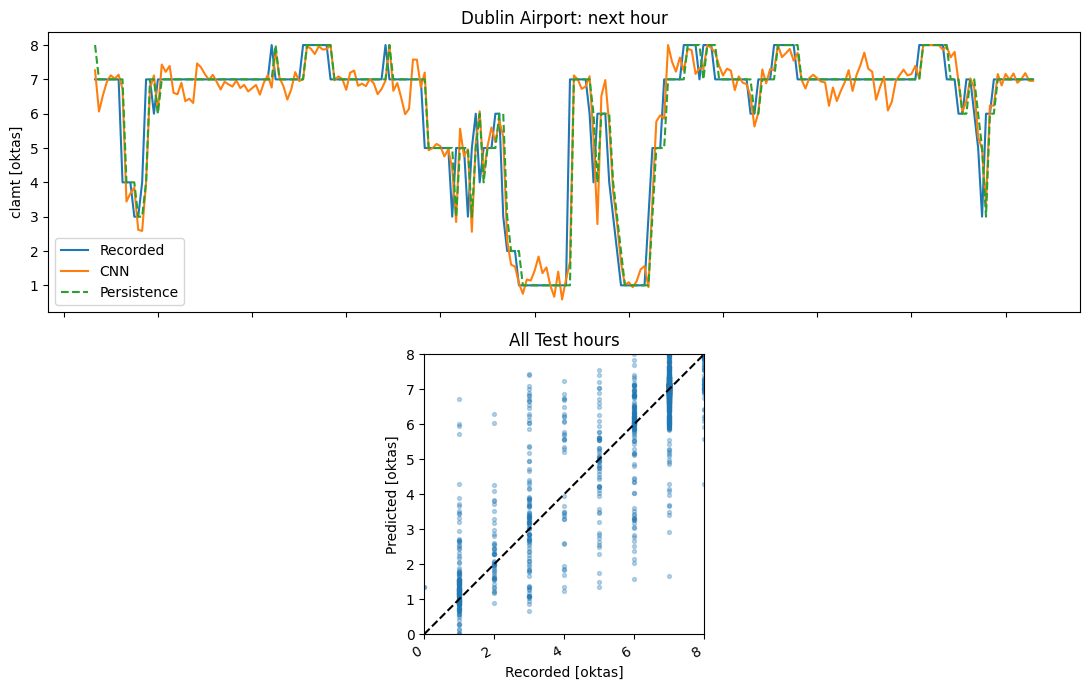

Test bias per station [oktas]: {'Dublin Airport': np.float32(0.011), 'Cork Airport': np.float32(0.037), 'Knock Airport': np.float32(-0.14), 'Shannon Airport': np.float32(0.074), 'Casement': np.float32(-0.05)}


In [43]:
station_names = ["Dublin Airport", "Cork Airport", "Knock Airport",
                 "Shannon Airport", "Casement"]
station = 0
count = min(240, len(test_idx))
times_test = sat_times[sample_t[test_idx] + H]
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(times_test[:count], y_true[:count, station], label="Recorded")
axes[0].plot(times_test[:count], preds[:count, station], label="CNN")
axes[0].plot(times_test[:count], persistence[:count, station], ls="--", label="Persistence")
axes[0].set(ylabel="clamt [oktas]", title=f"{station_names[station]}: next hour")
axes[0].legend()
axes[1].scatter(y_true[:, station], preds[:, station], alpha=0.3, s=8)
axes[1].plot([0, 8], [0, 8], ls="--", color="black")
axes[1].set(xlim=(0, 8), ylim=(0, 8), xlabel="Recorded [oktas]",
            ylabel="Predicted [oktas]", title="All Test hours")
axes[1].set_aspect("equal", adjustable="box")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
print("Test bias per station [oktas]:", dict(zip(
    station_names, np.round((preds - y_true).mean(axis=0), 3)
)))


## تجربة المحاضرة: 3 محاولات لـStation CNN

دي **إضافة اختيارية بعد تدريب Station CNN وقبل تجربة الخريطة** عشان تطلع نفس نوع الرسم اللي بعتيه. النسخة الكاملة كانت بتدرّب محاولة واحدة (predict change)، فمفيش 3 loss histories نقدر نرسمهم من غير ما ندرّب 3 محاولات. الإضافة دي ما بتغيّرش نموذج next-hour map ولا الـTest split.

هنستخدم نفس samples والـ70/15/15 split، وصور بحجم 45 × 60 بدل 90 × 120 هنا فقط لتقليل وقت الـablation على CPU. الثلاث محاولات: global spatial pool مع absolute target، spatial grid مع absolute target، ونفس spatial grid مع predict change. global pool هنا بيفقد **مكان** الغيم، لكن الوقت لسه موجود في channels؛ ده مختلف عن مثال Conv1d في المحاضرة.


In [44]:
ablation_frames = frames[:, :, ::2, ::2]
ablation_mean, ablation_std = channel_stats(ablation_frames, train_hours)

class AblationStationCNN(nn.Module):
    def __init__(self, grid):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(K * frames.shape[1], 16, stride=stride,
                      padding=padding, kernel_size=kernel_size),
            ConvBlock(16, 32, stride=stride,
                      padding=padding, kernel_size=kernel_size),
            ConvBlock(32, 64, stride=stride,
                      padding=padding, kernel_size=kernel_size),
        )
        self.pool = nn.AdaptiveAvgPool2d(grid)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * grid[0] * grid[1] + extra.shape[1], y.shape[1]),
        )

    def forward(self, images, other_inputs):
        batch, hours, channels, height, width = images.shape
        features = self.features(images.reshape(batch, hours * channels, height, width))
        features = self.pool(features).flatten(1)
        return self.head(torch.cat((features, other_inputs), dim=1))

print("Ablation image shape:", ablation_frames.shape)
print("Ablation input scaling from Train hours only:", len(train_hours))


Ablation image shape: (8784, 2, 45, 60)
Ablation input scaling from Train hours only: 6129


### وظيفة تدريب المحاولة الواحدة

كل محاولة هتبدأ بـseed واحد وTrain/Validation samples نفسها، وتستخدم forward → scaled MSE → backward → optimizer.step. بنرجع أفضل weights حسب Validation ونعمل early stopping. تغير الـtarget من absolute إلى delta بيغير الـscaling، لذلك **ارتفاع loss في لوحة ما ينفعش يتقارن رقميًا بلوحة تانية**؛ هنعتمد على RMSE بالـoktas للمقارنة.


In [45]:
def run_station_ablation(grid, predict_change, label):
    torch.manual_seed(42)
    target = y if predict_change else clamt_future
    target_mean = target[train_idx].mean(axis=0)
    target_std = target[train_idx].std(axis=0)
    target_std = np.where(target_std < 1e-6, 1.0, target_std)

    train_data = FrameDataset(ablation_frames, extra, target, sample_t, train_idx, K)
    validation_data = FrameDataset(ablation_frames, extra, target, sample_t, val_idx, K)
    training = torch.utils.data.DataLoader(
        train_data, batch_size=32, shuffle=True, num_workers=0
    )
    validation = torch.utils.data.DataLoader(
        validation_data, batch_size=64, num_workers=0
    )

    network = ScaledModel(
        AblationStationCNN(grid), ablation_mean, ablation_std,
        target_mean, target_std
    ).to(device)
    optimizer_a = torch.optim.AdamW(
        network.parameters(), lr=3e-4, weight_decay=1e-2
    )
    loss_fn = nn.MSELoss()
    history = {"Train": [], "Validation": []}
    best_loss, best_weights, best_epoch, stale = float("inf"), None, 0, 0

    for epoch in range(1, 13):
        network.train()
        running_train = 0.0
        for xb, eb, yb in training:
            xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
            optimizer_a.zero_grad()
            loss = loss_fn(network.forward_scaled(xb, eb), network.scale_y(yb))
            loss.backward()
            optimizer_a.step()
            running_train += loss.item() * len(xb)

        network.eval()
        running_validation = 0.0
        with torch.no_grad():
            for xb, eb, yb in validation:
                xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
                v = loss_fn(network.forward_scaled(xb, eb), network.scale_y(yb))
                running_validation += v.item() * len(xb)

        train_loss = running_train / len(train_data)
        val_loss = running_validation / len(validation_data)
        history["Train"].append(train_loss)
        history["Validation"].append(val_loss)
        print(f"{label} | epoch {epoch:02d} | Train {train_loss:.4f} | Validation {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss, best_epoch, stale = val_loss, epoch, 0
            best_weights = copy.deepcopy(network.state_dict())
        else:
            stale += 1
            if stale >= 3:
                break

    network.load_state_dict(best_weights)
    network.eval()
    return {"network": network, "history": history,
            "best_epoch": best_epoch, "delta": predict_change,
            "label": label}


### شغّلي المحاولات الثلاث

التغيير بين الأولى والتانية هو الاحتفاظ بالمكان في الصورة؛ وبين التانية والتالتة هو absolute target مقابل predict change. الخلية دي بتدرّب 3 models فعلًا، فممكن تاخد وقت على CPU. شغّليها مرة واحدة قبل خلية الرسم.


In [46]:
ablation_runs = {}
for label, grid, change in [
    ("Global pool, absolute", (1, 1), False),
    ("Spatial grid, absolute", (3, 4), False),
    ("Spatial grid, change", (3, 4), True),
]:
    ablation_runs[label] = run_station_ablation(grid, change, label)


Global pool, absolute | epoch 01 | Train 0.7235 | Validation 0.8152
Global pool, absolute | epoch 02 | Train 0.6327 | Validation 0.8305
Global pool, absolute | epoch 03 | Train 0.5930 | Validation 0.7231
Global pool, absolute | epoch 04 | Train 0.5626 | Validation 0.7288
Global pool, absolute | epoch 05 | Train 0.5462 | Validation 0.6658
Global pool, absolute | epoch 06 | Train 0.5308 | Validation 0.6498
Global pool, absolute | epoch 07 | Train 0.5159 | Validation 0.7558
Global pool, absolute | epoch 08 | Train 0.5140 | Validation 0.6286
Global pool, absolute | epoch 09 | Train 0.4992 | Validation 0.6714
Global pool, absolute | epoch 10 | Train 0.4946 | Validation 0.6177
Global pool, absolute | epoch 11 | Train 0.4880 | Validation 0.6163
Global pool, absolute | epoch 12 | Train 0.4800 | Validation 0.6342
Spatial grid, absolute | epoch 01 | Train 0.6448 | Validation 0.7278
Spatial grid, absolute | epoch 02 | Train 0.5370 | Validation 0.6734
Spatial grid, absolute | epoch 03 | Train 0.49

### رسم Train وValidation loss

ده مكان نفس نوع الرسم اللي بعتّيه: 3 panels كل واحدة لمحاولة منفصلة. الخط المتقطع عند أفضل epoch حسب Validation في **نفس المحاولة**. اختلاف مقياس target بين absolute وchange يمنع مقارنة ارتفاع خطوطهم مباشرة.


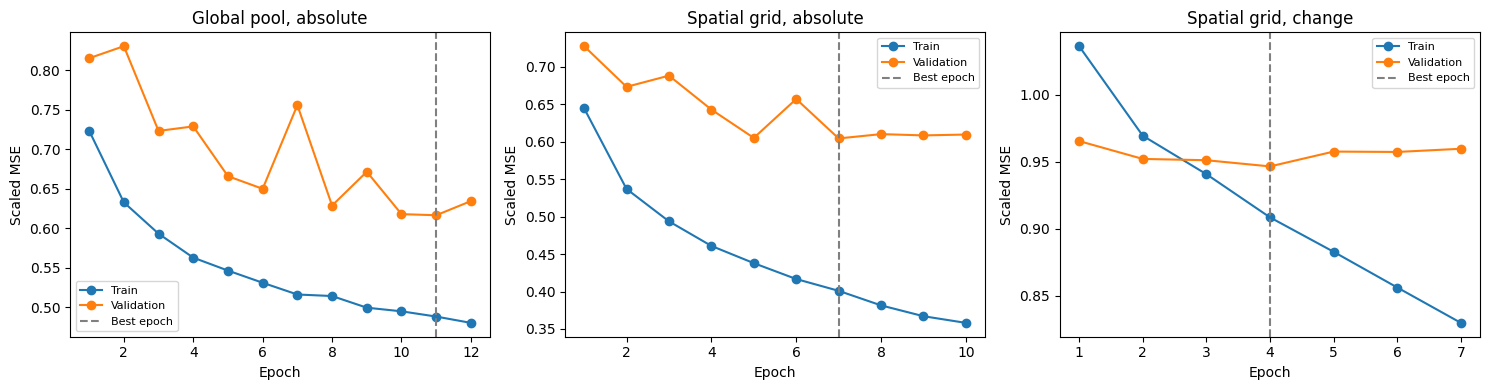

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, run) in zip(axes, ablation_runs.items()):
    epochs = np.arange(1, len(run["history"]["Train"]) + 1)
    ax.plot(epochs, run["history"]["Train"], marker="o", label="Train")
    ax.plot(epochs, run["history"]["Validation"], marker="o", label="Validation")
    ax.axvline(run["best_epoch"], color="grey", linestyle="--", label="Best epoch")
    ax.set(title=label, xlabel="Epoch", ylabel="Scaled MSE")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### المقارنة الصحيحة: Validation RMSE بالـoktas

بنرجع توقع كل محاولة للوحدة الأصلية: لو model بتتوقع change بنضيفه لقيمة المحطة الحالية. بعدها بنقارن كل المحاولات مع persistence على **نفس Validation samples**. الأقل RMSE أحسن؛ Test محجوز للتقييم النهائي بعد اختيار النموذج.


In [48]:
ablation_truth = clamt_future[val_idx]
persistence_val_rmse = overall_rmse(clamt_now[val_idx], ablation_truth)
print(f"Persistence | Validation RMSE {persistence_val_rmse:.3f} oktas")

for label, run in ablation_runs.items():
    validation_data = FrameDataset(
        ablation_frames, extra, y, sample_t, val_idx, K
    )
    loader = torch.utils.data.DataLoader(
        validation_data, batch_size=64, num_workers=0
    )
    forecast_parts = []
    run["network"].eval()
    with torch.no_grad():
        for xb, eb, _ in loader:
            forecast_parts.append(
                run["network"](xb.to(device), eb.to(device)).cpu().numpy()
            )
    predictions = np.concatenate(forecast_parts)
    if run["delta"]:
        predictions += clamt_now[val_idx]
    predictions = np.clip(predictions, 0, 8)
    print(f"{label:<25} | Validation RMSE "
          f"{overall_rmse(predictions, ablation_truth):.3f} oktas")


Persistence | Validation RMSE 1.206 oktas
Global pool, absolute     | Validation RMSE 1.572 oktas
Spatial grid, absolute    | Validation RMSE 1.537 oktas
Spatial grid, change      | Validation RMSE 1.189 oktas


# توقع خريطة الغيم بعد ساعة

**الجزء ده من المشروع الأصلي محفوظ كامل**: CNN–LSTM بتاخد ست خرائط satellite وتطلع cloud mask وcloud-top height للساعة الجاية. بعد التدريب بنعرض ست input maps وRecorded وPredicted بنفس الألوان الأزرق والأخضر والبنفسجي. هنا بس هنستخدم حدود تقسيم الوقت الجديدة؛ CSV مش inputs للخريطة.


بنستورد أدوات المسارات وحساب loss الخاصة بتجربة الخرائط. أسماء الـcheckpoints والـoutputs هنا مختلفة عن تجربة المحطات.


In [49]:
from pathlib import Path
from torch.nn import functional as F


بنختار 6 صور ساعية ورا بعض، والـtarget صورة الساعة اللي بعدها مباشرة. بنستبعد أي ساعة مافيهاش pixels صالحة، عشان الـmodel مايتعلمش من صور فاضية.


In [50]:
map_hour_ok = np.any(cloud_mask != 3, axis=(1, 2))
map_sample_t = np.array([
    t for t in range(K - 1, len(sat_times) - 1)
    if map_hour_ok[t - K + 1:t + 2].all()
])


تجربة الخريطة هتستخدم نفس حدود ساعات السنة 70/15/15: Train ثم Validation ثم Test، وكل input والـtarget ضمن قسم واحد.


In [51]:
map_first_input = map_sample_t - K + 1
map_target_hour = map_sample_t + 1
map_idx = np.arange(len(map_sample_t))
map_train_idx = map_idx[map_target_hour < train_end]
map_val_idx = map_idx[
    (map_first_input >= train_end) & (map_target_hour < validation_end)
]
map_test_idx = map_idx[map_first_input >= validation_end]


بنتأكد إن الساعات المستخدمة في مدخلات وtarget كل قسم **مش مشتركة** مع القسمين التانيين. مش كفاية بس إن أرقام الصفوف مختلفة؛ لازم ساعات الصور نفسها ما تتداخلش.


In [52]:
def used_map_hours(indices):
    last_inputs = map_sample_t[indices]
    return set(np.concatenate(
        [last_inputs - offset for offset in range(K)] + [last_inputs + 1]
    ))

map_train_hours = used_map_hours(map_train_idx)
map_validation_hours = used_map_hours(map_val_idx)
map_test_hours = used_map_hours(map_test_idx)
assert map_train_hours.isdisjoint(map_validation_hours)
assert map_train_hours.isdisjoint(map_test_hours)
assert map_validation_hours.isdisjoint(map_test_hours)


بنطبع أحجام Train/Validation/Test ونشوف أول 6 ساعات input وساعة target. لازم الـtarget يبقى بعد آخر input بساعة واحدة.


In [53]:
map_total = sum(map(len, (map_train_idx, map_val_idx, map_test_idx)))
for name, indices in [
    ("Train", map_train_idx), ("Validation", map_val_idx),
    ("Test", map_test_idx),
]:
    print(f"{name}: {len(indices)} ({100 * len(indices) / map_total:.1f}%)")
print("Verified: input and target hours do not overlap across splits.")
print("First six input times:", sat_times[map_sample_t[0] - K + 1:map_sample_t[0] + 1])
print("First next-hour target:", sat_times[map_sample_t[0] + 1])


Train: 6104 (69.9%)
Validation: 1312 (15.0%)
Test: 1312 (15.0%)
Verified: input and target hours do not overlap across splits.
First six input times: ['2024-01-01T00:00:00.000000' '2024-01-01T01:00:00.000000'
 '2024-01-01T02:00:00.000000' '2024-01-01T03:00:00.000000'
 '2024-01-01T04:00:00.000000' '2024-01-01T05:00:00.000000']
First next-hour target: 2024-01-01T06:00:00.000000


## صور الـinput والـtarget

كل ساعة input فيها 3 channels بحجم `90 × 120`: cloud mask ثنائي، cloud-top height مقسوم على `12 km`، وvalid-pixel mask. الـtarget هو cloud map وheight map للساعة الجاية، ومعاهم masks للصلاحية. الـno data ما تدخلش في loss، والـheight loss تتحسب على الغيم المرصود بس.


بنعرّف Map Dataset اللي بترجع الصور الست، وصورتي الـtarget للساعة الجاية، وmasks البيكسلات الصالحة. كل sample بيحتفظ بتوزيع الصورة المكاني.


In [54]:
class NextHourMapDataset(torch.utils.data.Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        t = map_sample_t[self.indices[item]]
        previous = frames[t - K + 1:t + 1].astype(np.float32)
        cloud_inputs = previous[:, 0]
        height_inputs = np.clip(previous[:, 1] / 12, 0, 1)
        valid_inputs = (cloud_mask[t - K + 1:t + 1] != 3).astype(np.float32)
        images = np.stack((cloud_inputs, height_inputs, valid_inputs), axis=1)

        target_mask = cloud_mask[t + 1]
        target_cloud = (target_mask == 2).astype(np.float32)[None]
        target_height = np.clip(frames[t + 1, 1].astype(np.float32) / 12, 0, 1)[None]
        target_valid = (target_mask != 3).astype(np.float32)[None]
        height_valid = (target_mask == 2).astype(np.float32)[None]

        return tuple(torch.from_numpy(array) for array in (
            images, target_cloud, target_height, target_valid, height_valid,
        ))


بنجهز Map Datasets لـTrain وValidation وTest حسب حدود التقسيم الزمني 70/15/15 اللي حددناها. الـCSV مش inputs في تجربة الخرائط.


In [55]:
map_train_dataset = NextHourMapDataset(map_train_idx)
map_val_dataset = NextHourMapDataset(map_val_idx)
map_test_dataset = NextHourMapDataset(map_test_idx)


بنحمّل الخرائط بـ`batch_size=8`. الخرائط والتدرجات بتستهلك RAM، فده حجم مناسب كبداية؛ لو هنغيره نقارن Validation loss بنفس تقسيم الداتا.


In [56]:
map_train_loader = torch.utils.data.DataLoader(
    map_train_dataset, batch_size=8, shuffle=True, num_workers=0
)
map_val_loader = torch.utils.data.DataLoader(
    map_val_dataset, batch_size=8, num_workers=0
)
map_test_loader = torch.utils.data.DataLoader(
    map_test_dataset, batch_size=8, num_workers=0
)


بنتأكد إن الـinput لكل sample شكله `(6,3,90,120)`، والـtarget لكل خريطة `(1,90,120)`. مراجعة الـshapes دي تمنع غلطة عدد الـchannels قبل تدريب CNN.


In [57]:
example_images, example_cloud, example_height, _, _ = map_train_dataset[0]
print("Input images:", example_images.shape)
print("Next-hour cloud target:", example_cloud.shape)
print("Next-hour height target:", example_height.shape)


Input images: torch.Size([6, 3, 90, 120])
Next-hour cloud target: torch.Size([1, 90, 120])
Next-hour height target: torch.Size([1, 90, 120])


## CNN–LSTM: الصور الست بتوصل للخريطة المتوقعة إزاي؟

نفس CNN، **بنفس الأوزان**، بتشتغل على كل صورة ساعة. بعدها LSTM بتقرأ الـfeatures بترتيب الوقت. الأبعاد تحت لكل sample من غير batch dimension:

| الـlayer | الـinput → الـoutput | الـparameters ووظيفتها |
| --- | --- | --- |
| CNN layer 1 | `3 × 90 × 120` → `8 × 45 × 60` | `Conv2d(3,8,kernel_size=3,stride=2,padding=1)` وبعدها `ReLU`؛ تلتقط أنماط محلية وتصغر الصورة. |
| CNN layer 2 | `8 × 45 × 60` → `16 × 23 × 30` | `Conv2d(8,16,kernel_size=3,stride=2,padding=1)` وبعدها `ReLU`. **مفيش pooling**؛ التصغير جاي من `stride=2`. |
| Spatial LSTM | `6 × 16 × 23 × 30` → `16 × 23 × 30` | بنرتبهم كـ`690 = 23 × 30` sequences؛ كل مكان ليه 6 steps و16 features. `input_size=16,hidden_size=16`، والـgates الداخلية فيها `sigmoid` و`tanh`. بناخد آخر hidden output. |
| Upsample وskip connection | `16 × 23 × 30` → `16 × 90 × 120` → `19 × 90 × 120` | `bilinear interpolation` ترجع الحجم الأصلي، وبنضيف آخر صورة كاملة ذات 3 channels عشان نحتفظ بتفاصيل صغيرة. |
| Decoder CNN | `19 × 90 × 120` → `16 × 90 × 120` → `16 × 90 × 120` | اتنين `3 × 3 Conv` مع `stride=1,padding=1` و`ReLU`؛ حجم الخريطة بيفضل ثابت. |
| Cloud head | `16 × 90 × 120` → `1 × 90 × 120` | `1 × 1 Conv` بتصحح تقدير آخر cloud mask. أثناء التدريب بنستخدم raw `logits`؛ وللرسم `sigmoid ≥ 0.5` يحولها لـcloud/clear. |
| Height head | `16 × 90 × 120` → `1 × 90 × 120` | `1 × 1 Conv` بتصحح الارتفاع، و`sigmoid` يخليه بين 0 و1؛ نضرب ×12 عشان نعرض km. |

الـ8 والـ16 في CNN هما **feature channels**. `hidden_size=16` يعني 16 hidden features **لكل واحد من الـ690 positions**، مش 16 pixels للخريطة كلها. الـskip connection بتساعد في التفاصيل، لكن مش شرط ترجع كل التفاصيل اللي راحت بسبب downsampling. أي زيادة في عدد الـfilters أو hidden_size لازم نقيمها بالـValidation.


بنعرّف CNN–LSTM بالـcloud head والـheight head. الـforward pass هنا بيطلع خريطتين؛ استدعاء الـmodel لوحده مش معناه إن حصل backward pass أو تحديث أوزان.


In [58]:
class NextHourCloudMapModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.map_lstm = nn.LSTM(16, 16, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Conv2d(16 + 3, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
        )
        self.cloud_head = nn.Conv2d(16, 1, 1)
        self.height_head = nn.Conv2d(16, 1, 1)

    def forward(self, images):
        batch, hours, channels, height, width = images.shape
        encoded = self.encoder(
            images.reshape(batch * hours, channels, height, width)
        )
        _, features, small_h, small_w = encoded.shape
        encoded = encoded.reshape(batch, hours, features, small_h, small_w)
        sequences = encoded.permute(0, 3, 4, 1, 2).reshape(
            batch * small_h * small_w, hours, features
        )
        sequences, _ = self.map_lstm(sequences)
        spatial = sequences[:, -1].reshape(batch, small_h, small_w, 16)
        spatial = spatial.permute(0, 3, 1, 2)
        spatial = F.interpolate(
            spatial, size=(height, width), mode="bilinear", align_corners=False
        )

        last_image = images[:, -1]  # retains full 90 x 120 detail
        decoded = self.decoder(torch.cat((spatial, last_image), dim=1))
        cloud_logits = 4 * last_image[:, 0:1] - 2 + self.cloud_head(decoded)

        previous_height = torch.where(
            last_image[:, 0:1] > 0.5,
            last_image[:, 1:2],
            torch.full_like(last_image[:, 1:2], 0.5),
        ).clamp(0.01, 0.99)
        predicted_height = torch.sigmoid(
            torch.logit(previous_height) + self.height_head(decoded)
        )
        return cloud_logits, predicted_height


بننشئ Map Model على GPU لو متاحة، وإلا CPU. الـbatch لازم تبقى على نفس الـdevice.


In [59]:
map_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
map_model = NextHourCloudMapModel().to(map_device)
print("Cloud-map device:", map_device)


Cloud-map device: cpu


بنجرب forward pass من غير gradients ونتأكد إن كل output شكله `(batch,1,90,120)` زي الـtarget. ده اختبار shape قبل التدريب.


In [60]:
with torch.no_grad():
    cloud_logits, predicted_height = map_model(
        example_images[None].to(map_device)
    )
print("Model outputs:", cloud_logits.shape, predicted_height.shape)


Model outputs: torch.Size([1, 1, 90, 120]) torch.Size([1, 1, 90, 120])


## Map loss والـbackward pass

الـcloud head بتطلع raw `logits`، فبنستخدم `binary_cross_entropy_with_logits` على **الـvalid pixels بس**. والـheight head بنحسب لها `smooth_l1_loss` على pixels اللي فيها غيم مرصود وارتفاع صالح؛ السماء الصافية مافيهاش cloud-top height نقارنه. أثناء التدريب الـheight متقسّم على `12 km`.

الـcombined loss = `cloud loss + 5 × height loss`. الرقم **5 مجرد وزن** يخلي خسارة الارتفاع ليها تأثير مناسب؛ مش معناه 5 km خطأ. في كل batch: `zero_grad → forward` يطلع الخريطتين، نحسب loss، نعمل `loss.backward()` خلال الـheads والـdecoder وLSTM وCNN، وبعدها `Adam(lr=0.001).step()` يحدث الأوزان. بنختار أفضل checkpoint بأقل Validation loss، ونوقف لو 3 epochs ما حسّنوهاش. لو هنجرب وزن تاني بدل 5 أو learning rate مختلف، نختاره من Validation مش Test.


بنكتب دالة الـloss: BCE للغيم على valid pixels، وSmoothL1 لارتفاع الغيم على cloudy valid pixels. الـcombined loss هنا مش بالكيلومتر.


In [61]:
def map_loss(scores, predicted_h, target_cloud, target_h, valid, height_valid):
    cloud_loss = F.binary_cross_entropy_with_logits(
        scores[valid.bool()], target_cloud[valid.bool()]
    )
    cloudy_pixels = height_valid.bool()
    if cloudy_pixels.any():
        height_loss = F.smooth_l1_loss(
            predicted_h[cloudy_pixels], target_h[cloudy_pixels]
        )
    else:
        height_loss = cloud_loss.new_zeros(())
    return cloud_loss + 5 * height_loss


بنجهز metrics: `cloud IoU = intersection / union` وكل ما تزيد يبقى أحسن، و`height MAE` بالكيلومتر وكل ما تقل يبقى أحسن. وبنقارن بـlast-map baseline اللي بتعتبر آخر صورة هي توقع الساعة الجاية.


In [62]:
@torch.no_grad()
def map_metrics(loader, baseline=False):
    map_model.eval()
    loss_total = intersection = union = height_error = height_count = 0.0
    for batch in loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        if baseline:
            cloud_prediction = images[:, -1, 0:1] > 0.5
            predicted_h = images[:, -1, 1:2]
        else:
            scores, predicted_h = map_model(images)
            loss_total += map_loss(
                scores, predicted_h, cloud, height, valid, height_valid
            ).item() * len(images)
            cloud_prediction = torch.sigmoid(scores) >= 0.5

        valid_pixels = valid.bool()
        actual_cloud = cloud.bool()
        intersection += (
            cloud_prediction & actual_cloud & valid_pixels
        ).sum().item()
        union += (
            (cloud_prediction | actual_cloud) & valid_pixels
        ).sum().item()
        height_pixels = height_valid.bool()
        height_error += (
            (predicted_h[height_pixels] - height[height_pixels]).abs().sum().item()
            * 12
        )
        height_count += height_pixels.sum().item()

    return (
        loss_total / len(loader.dataset) if not baseline else float("nan"),
        100 * intersection / union,
        height_error / height_count,
    )


### Last-map persistence قبل تدريب CNN–LSTM

بنقيس cloud IoU وheight MAE لما نعتبر آخر صورة هي توقع الساعة الجاية. دي baseline اللي الـmodel هيقارن نفسه بيها، وTest مش هنستخدمها في اختيار hyperparameters.


In [63]:
_, baseline_val_iou, baseline_val_height = map_metrics(map_val_loader, baseline=True)
_, baseline_test_iou, baseline_test_height = map_metrics(map_test_loader, baseline=True)
print(f"Last map Validation: IoU {baseline_val_iou:.1f}% | "
      f"height MAE {baseline_val_height:.2f} km")
print(f"Last map Test: IoU {baseline_test_iou:.1f}% | "
      f"height MAE {baseline_test_height:.2f} km")


Last map Validation: IoU 82.7% | height MAE 1.47 km
Last map Test: IoU 83.8% | height MAE 1.58 km


بنجهز مكان حفظ أفضل Map Model، و`Adam` بـ`learning rate=0.001`، وقوايم losses لكل epoch. كل تجربة بإعدادات جديدة لازم تبقى ليها قوائم وcheckpoint واضحين.


In [64]:
map_output_dir = Path("outputs/project2_next_cloud_map_one_hour_aligned")
map_output_dir.mkdir(parents=True, exist_ok=True)
map_checkpoint = map_output_dir / "best_next_cloud_map.pt"
map_optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)
map_train_history, map_val_history = [], []
best_map_loss = float("inf")
stale_map_epochs = 0


بندرّب بحد أقصى 8 epochs، ومع early stopping بعد 3 epochs من غير تحسن في Validation. لكل batch الترتيب هو `zero_grad → forward → loss → backward → step`. بنحفظ checkpoint لأقل combined Validation loss.


In [65]:
for map_epoch in range(1, 9):
    map_model.train()
    training_total = 0.0
    for batch in map_train_loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        map_optimizer.zero_grad()
        scores, predicted_h = map_model(images)
        loss = map_loss(scores, predicted_h, cloud, height, valid, height_valid)
        loss.backward()
        map_optimizer.step()
        training_total += loss.item() * len(images)

    training_loss = training_total / len(map_train_dataset)
    validation_loss, validation_iou, validation_height_mae = map_metrics(
        map_val_loader
    )
    map_train_history.append(training_loss)
    map_val_history.append(validation_loss)
    print(
        f"Epoch {map_epoch:02d} | Train loss {training_loss:.4f} | "
        f"Validation loss {validation_loss:.4f} | "
        f"Cloud IoU {validation_iou:.1f}% | "
        f"Height MAE {validation_height_mae:.2f} km",
        flush=True,
    )
    if validation_loss < best_map_loss:
        best_map_loss = validation_loss
        stale_map_epochs = 0
        torch.save(map_model.state_dict(), map_checkpoint)
        print("  Saved best next-hour map model", flush=True)
    else:
        stale_map_epochs += 1
        if stale_map_epochs >= 3:
            print("Stopped after three epochs without validation improvement")
            break


Epoch 01 | Train loss 0.4142 | Validation loss 0.3985 | Cloud IoU 84.1% | Height MAE 1.44 km
  Saved best next-hour map model
Epoch 02 | Train loss 0.3732 | Validation loss 0.3819 | Cloud IoU 84.3% | Height MAE 1.34 km
  Saved best next-hour map model
Epoch 03 | Train loss 0.3647 | Validation loss 0.3784 | Cloud IoU 84.4% | Height MAE 1.44 km
  Saved best next-hour map model
Epoch 04 | Train loss 0.3607 | Validation loss 0.3762 | Cloud IoU 84.4% | Height MAE 1.38 km
  Saved best next-hour map model
Epoch 05 | Train loss 0.3580 | Validation loss 0.3662 | Cloud IoU 84.5% | Height MAE 1.34 km
  Saved best next-hour map model
Epoch 06 | Train loss 0.3561 | Validation loss 0.3675 | Cloud IoU 84.5% | Height MAE 1.31 km
Epoch 07 | Train loss 0.3543 | Validation loss 0.3642 | Cloud IoU 84.6% | Height MAE 1.35 km
  Saved best next-hour map model
Epoch 08 | Train loss 0.3533 | Validation loss 0.3627 | Cloud IoU 84.6% | Height MAE 1.35 km
  Saved best next-hour map model


بنحمّل أفضل checkpoint حسب الـValidation قبل ما نقيّم Test ونرسم الخرائط. آخر epoch مش لازم تكون الأفضل.


In [66]:
map_model.load_state_dict(
    torch.load(map_checkpoint, map_location=map_device, weights_only=True)
)
map_model.eval()
print("Best model:", map_checkpoint)


Best model: outputs\project2_next_cloud_map_one_hour_aligned\best_next_cloud_map.pt


## تقييم الخرائط والأخطاء

هنقارن جودة الـcloud mask والـcloud-top height وبعدين نبص على الصور نفسها. أرقام map loss مختلفة تمامًا عن scaled MSE في تجربة المحطات.


### قراءة Map loss graph

Map loss بتجمع cloud classification و5 × cloud-top-height error على valid pixels. Train نازلة وValidation طالعة عدة epochs مؤشر overfitting؛ ثباتهم عدة epochs plateau. أرقام التشغيل القديم بتقسيم الأسابيع مش هتنطبق هنا، فهنفسّر الرسم بعد التدريب الجديد.


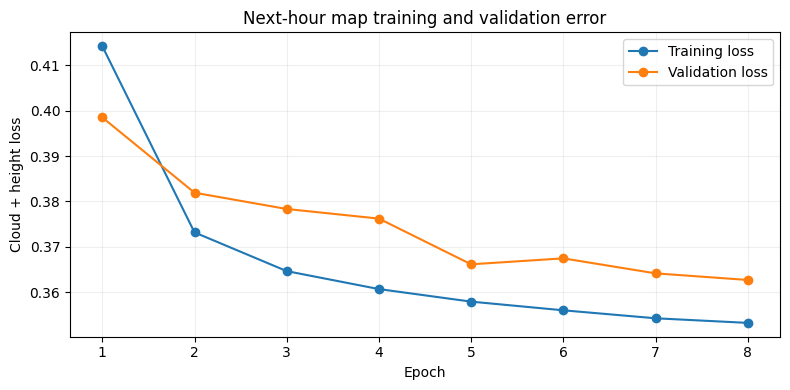

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(map_train_history) + 1)
ax.plot(epochs, map_train_history, marker="o", label="Training loss")
ax.plot(epochs, map_val_history, marker="o", label="Validation loss")
ax.set(xlabel="Epoch", ylabel="Cloud + height loss",
       title="Next-hour map training and validation error")
ax.set_xticks(epochs)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(map_output_dir / "training_error.png", dpi=160)
plt.show()


بنقارن Map CNN–LSTM مع last-map baseline على **نفس** Test weeks. `IoU` نسبة للغيم (الأعلى أحسن)، و`height MAE` بالكيلومتر (الأقل أحسن)؛ لازم نبص على الاتنين.


In [68]:
test_loss, test_iou, test_height_mae = map_metrics(map_test_loader)
_, baseline_iou, baseline_height_mae = map_metrics(map_test_loader, baseline=True)
print(f"CNN–LSTM | Test cloud IoU: {test_iou:.1f}% | "
      f"Height MAE: {test_height_mae:.2f} km")
print(f"Last map | Test cloud IoU: {baseline_iou:.1f}% | "
      f"Height MAE: {baseline_height_mae:.2f} km")


CNN–LSTM | Test cloud IoU: 85.7% | Height MAE: 1.42 km
Last map | Test cloud IoU: 83.8% | Height MAE: 1.58 km


## رسم الصور الحقيقية والمتوقعة

هنعرض الست صور اللي دخلت الـmodel، والصورة الحقيقية للساعة الجاية، والصورة اللي الـCNN–LSTM توقعتها. بعد كده هنحدد أماكن الأخطاء بدل الاعتماد على شكل الصورة بس.


بنستورد أدوات الـcolormap والإحداثيات. نفس الـpalette ونفس حدود الألوان هيخلو مقارنة الصور عادلة بصريًا.


In [69]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

try:
    import cartopy.crs as ccrs
except ImportError:
    ccrs = None  # Geographic coordinates still plot without Cartopy.


بنختار sample واحد من Test عشان نشوفه بصريًا. مثال واحد ممكن يكون سهل أو صعب، فالأرقام المجمعة لكل Test بتفضل أهم.


In [70]:
map_example_number = 100


بنمرر الصور الست على الـmodel بعد التدريب مع إيقاف gradients. ده inference بس؛ مفيش backward pass ولا تحديث weights.


In [71]:
input_images, actual_cloud_t, actual_h_t, valid_t, _ = map_test_dataset[
    map_example_number
]
map_last_hour = map_sample_t[map_test_idx[map_example_number]]
with torch.no_grad():
    map_scores, map_height = map_model(input_images[None].to(map_device))


بنحوّل الـoutputs والـtargets لـarrays للرسم. بنضرب ارتفاع النموذج ×12 عشان نرجعه لـkm. الـcloud map ناتجة من threshold، والـheight prediction تقدير من الـmodel مش قياس satellite جديد.


In [72]:
pred_cloud = (torch.sigmoid(map_scores[0, 0]) >= 0.5).cpu().numpy()
pred_height_km = (map_height[0, 0] * 12).cpu().numpy()
actual_cloud_map = actual_cloud_t[0].bool().numpy()
actual_height_km = actual_h_t[0].numpy() * 12
valid_pixels = valid_t[0].bool().numpy()


بنقرأ `lat` و`lon` ونختار أوقات الست صور ووقت الـtarget. العناوين فوق كل خريطة بتساعدنا نتاكد من ترتيب الساعات.


In [73]:
lat = sat_data["lat"]
lon = sat_data["lon"]
observed_positions = list(range(map_last_hour - K + 1, map_last_hour + 2))


بنرجّع خلفية البحر واليابسة في الخريطة المتوقعة من صور معروفة. الـmodel **ما بيتوقعش نوع الأرض**؛ الأزرق والأخضر مجرد خلفية، والـcloud/height هما التوقع.


In [74]:
land_pixels = np.any(cloud_mask[map_sample_t[map_train_idx]] == 1, axis=0)
predicted_mask = np.where(land_pixels, 1, 0).astype(np.uint8)
predicted_mask[pred_cloud] = 2
predicted_mask[cloud_mask[map_last_hour] == 3] = 3


بنثبت نفس الألوان: الأزرق `#0161c2` للبحر الصافي، الأخضر `#09773e` لليابسة الصافية، البنفسجي `#8e63b9` للغيم، والأبيض للـno data. فوق الـcloud pixels بنستخدم `Purples` لارتفاع القمم من 0 لـ12 km.


In [75]:
background = ListedColormap(["#0161c2", "#09773e", "#8e63b9", "#ffffff"])
mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)
projection = {"projection": ccrs.PlateCarree()} if ccrs else {}
transform = {"transform": ccrs.PlateCarree()} if ccrs else {}


بنرسم 6 input maps، وبعدهم actual next hour وpredicted next hour. نفس تدريج الارتفاع في كل لوحة مهم؛ درجة البنفسجي بتوضح ارتفاع الغيم، مش confidence الـmodel.


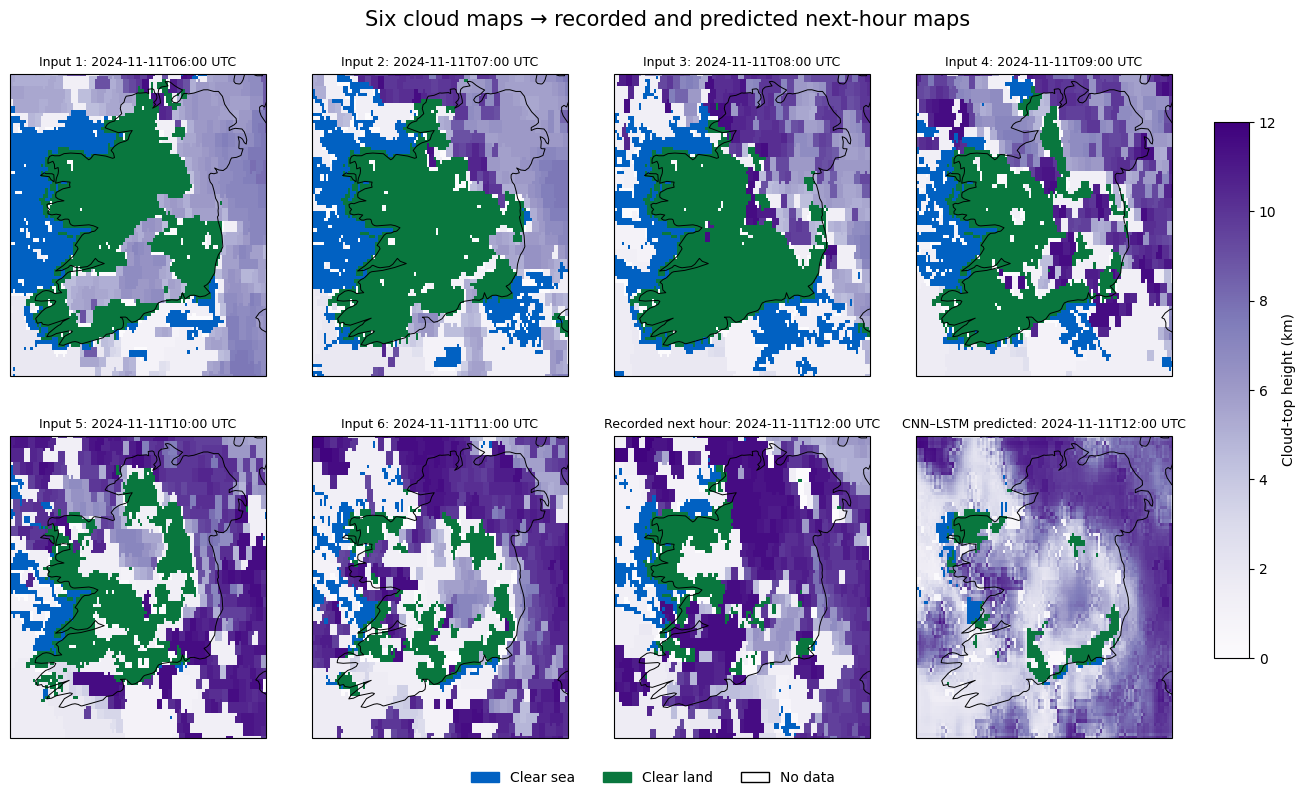

In [76]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8), subplot_kw=projection)
fig.subplots_adjust(left=0.03, right=0.86, bottom=0.07, top=0.90,
                    wspace=0.18, hspace=0.20)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = observed_positions[panel]
        panel_mask = cloud_mask[position]
        panel_height = frames[position, 1].astype(np.float32)
        title = f"Input {panel + 1}" if panel < 6 else "Recorded next hour"
    else:
        position = map_last_hour + 1
        panel_mask = predicted_mask
        panel_height = pred_height_km
        title = "CNN–LSTM predicted"

    ax.pcolormesh(lon, lat, panel_mask, cmap=background, norm=mask_norm,
                  shading="auto", **transform)
    coloured_clouds = ax.pcolormesh(
        lon, lat, np.ma.masked_where(panel_mask != 2, panel_height),
        cmap="Purples", vmin=0, vmax=12, shading="auto", **transform
    )
    if ccrs:
        ax.coastlines(resolution="50m", color="black", linewidth=0.7)
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("auto")
    ax.set_title(f"{title}: {str(sat_times[position])[:16]} UTC", fontsize=9)

fig.suptitle("Six cloud maps → recorded and predicted next-hour maps", fontsize=15)
fig.legend(handles=[
    Patch(color="#0161c2", label="Clear sea"),
    Patch(color="#09773e", label="Clear land"),
    Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
], loc="lower center", ncol=3, frameon=False)
fig.colorbar(coloured_clouds, cax=fig.add_axes([0.89, 0.17, 0.025, 0.67]),
             label="Cloud-top height (km)")
fig.savefig(map_output_dir / "recorded_vs_predicted.png", dpi=160,
            bbox_inches="tight")
plt.show()

# Error maps for this example; never use the recorded target as a model input.


بنفرّق بين false cloud (الـmodel توقع غيم ومفيش غيم مرصود) وmissed cloud (غيم مرصود الـmodel فوّته). كمان بنحسب فرق الارتفاع المطلق في الأماكن اللي ينفع نقارنها.


In [77]:
pixel_error = np.zeros_like(predicted_mask)
pixel_error[pred_cloud & ~actual_cloud_map & valid_pixels] = 1  # false cloud
pixel_error[~pred_cloud & actual_cloud_map & valid_pixels] = 2  # missed cloud
pixel_error[~valid_pixels] = 3
error_cmap = ListedColormap(["#e4f3e4", "#ff9933", "#d63247", "#ffffff"])
error_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], error_cmap.N)
height_error_map = np.ma.masked_where(
    ~actual_cloud_map, np.abs(pred_height_km - actual_height_km)
)


بنرسم أخطاء الـcloud pixels والـabsolute height error. تجمع الأخطاء عند أطراف الغيم بيدينا فكرة عن نوع الغلط؛ خطأ الارتفاع هنا بالكيلومتر، مش نفس رقم training loss.


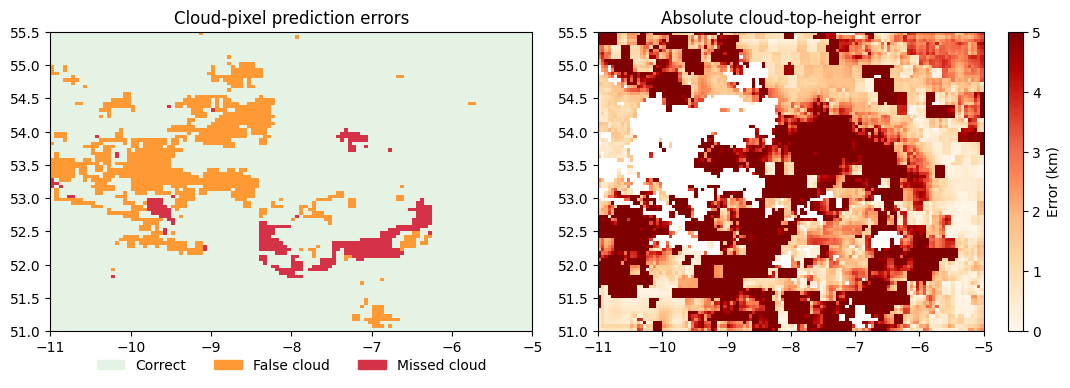

In [78]:
fig, (ax_cloud, ax_height) = plt.subplots(1, 2, figsize=(11, 4))
ax_cloud.pcolormesh(lon, lat, pixel_error, cmap=error_cmap,
                    norm=error_norm, shading="auto")
ax_cloud.set_title("Cloud-pixel prediction errors")
ax_cloud.legend(handles=[
    Patch(color="#e4f3e4", label="Correct"),
    Patch(color="#ff9933", label="False cloud"),
    Patch(color="#d63247", label="Missed cloud"),
], loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
colours = ax_height.pcolormesh(lon, lat, height_error_map,
                               cmap="OrRd", vmin=0, vmax=5, shading="auto")
ax_height.set_title("Absolute cloud-top-height error")
fig.colorbar(colours, ax=ax_height, label="Error (km)")
fig.tight_layout()
fig.savefig(map_output_dir / "example_error_maps.png", dpi=160,
            bbox_inches="tight")
plt.show()


بنطبع مكان الصور والـerror plots اللي اتحفظت. نقدر نستخدم الرسومات دي جنب أرقام Test عشان نشرح النتيجة بشكل واضح.


In [79]:
print("Saved training_error.png, recorded_vs_predicted.png, and "
      "example_error_maps.png in", map_output_dir.resolve())


Saved training_error.png, recorded_vs_predicted.png, and example_error_maps.png in D:\PhD\radar_cnn_lstm\outputs\project2_next_cloud_map_one_hour_aligned
